# Synthetischer Datensatz — Datensynthese

Erzeugt den synthetischen Datenstrom und speichert ihn als **Rohdaten** (Artefakt `data_raw`) im `data_dir`; die Vorverarbeitung (gleitender Mittelwert) erfolgt bewusst erst in *syn_model* — konsistent zu *tep*. *syn_model* und *syn_detection* laden von hier weiter.

In [1]:
FORCE_RECOMPUTE = False
IS_FINAL = True

In [2]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (plot_dir, data_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [3]:
from src.utils import thesis_style as ts

TEXTWIDTH_PT = ts.TEXTWIDTH_PT
INCH_PER_PT = ts.INCH_PER_PT
fig_width_in = ts.apply_rc()

In [4]:
import numpy as np

In [5]:
# --- Hash-relevante Parameter (lokale Arbeitswerte) ---
SEED = 42
Ts   = 1.0

NUM_SEGMENTS   = 5
CD_MIN, CD_MAX = -0.5, 0.5

RANGE_W1, N_CHANGES_W1 = (0, 5), 500
RANGE_W2, N_CHANGES_W2 = (0, 10), 750
KAPPA_W_FACTOR = 4 / 5

K_ACT, T_ACT_1, T_ACT_2 = 1.0, 4.0, 5.0

ALPHA_1 = 2 / 5
ALPHA_2 = 1 / 3
BETA    = 1 / 5
KAPPA   = 3 / 8
T_Y     = 3.0

N_DOE, HOLD_S = 128, 600

NOISE_U1 = [(0.02, 0.6), (0.12, 0.35), (0.5, 0.05)]   # (sigma, weight)
NOISE_U2 = [(0.003, 0.9), (0.02, 0.08), (0.2, 0.02)]
NOISE_Y  = [(0.003, 9.0), (0.02, 0.8), (0.08, 0.2)]

GAMMA_TAU   = 0.2   # Verschiebungsanteil der Segmentgrenzen
K_P         = 1.0   # Verstaerkung des Prozess-PT1
CD_BAND_DIV = 4     # Teiler der Startniveau-Baender (c_min/DIV, c_max/DIV)

In [6]:
from src.utils import run_registry as rr

run_cfg = {
    "seed": SEED, "Ts": Ts,
    "num_segments": NUM_SEGMENTS, "cd_range": [CD_MIN, CD_MAX],
    "range_w1": list(RANGE_W1), "n_changes_w1": N_CHANGES_W1,
    "range_w2": list(RANGE_W2), "n_changes_w2": N_CHANGES_W2,
    "kappa_w_factor": KAPPA_W_FACTOR,
    "K_act": K_ACT, "T_act": [T_ACT_1, T_ACT_2],
    "alpha": [ALPHA_1, ALPHA_2], "beta": BETA, "kappa": KAPPA, "T_y": T_Y,
    "n_doe": N_DOE, "hold_s": HOLD_S,
    "noise_u1": NOISE_U1, "noise_u2": NOISE_U2, "noise_y": NOISE_Y,
    "gamma_tau": GAMMA_TAU, "K_p": K_P, "cd_band_div": CD_BAND_DIV,
}

rng = np.random.default_rng(SEED)
data_cfg = rr.RunConfig(run_cfg)
run_id = data_cfg.id

# Konsistenz-Ledger: Datengenerierung ist die Wurzel (keine Vorstufen)
ledger = rr.run_ledger(work_dir)
ledger.bind("data")

data_store = rr.synthetic_data_store(data_dir)
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

_data_loaded_from_cache = data_store.exists("data_raw", data_cfg, rekey=True) and not FORCE_RECOMPUTE
print(f"run_id = {run_id}")

run_id = 3d16c559


## Create synthetic data stream

In [7]:
time = np.arange(0, 86400*365, Ts)

if _data_loaded_from_cache:
    data = data_store.load("data_raw", data_cfg, rename=True, rekey=True)
    print(f"Data aus Cache geladen: {data.shape[0]} Zeitschritte, {data.shape[1]} Variablen")
else:
    import numpy as np
    import pandas as pd

    datetime_idx = pd.to_datetime(time, unit='s', origin=pd.Timestamp("1970-01-01"))
    data = pd.DataFrame(index=datetime_idx)
    print(f"Data erzeugt: {data.shape[0]} Zeitschritte, {data.shape[1]} Variablen")

Data aus Cache geladen: 31536000 Zeitschritte, 18 Variablen


## Creation of Concept drift

In [8]:
if not _data_loaded_from_cache:
    num_segments = NUM_SEGMENTS
    BAND_FRACTION = 1.0 / CD_BAND_DIV  # Bandbreite: Anteil von `half`, ab dem ein Level liegen darf

    mid = (CD_MIN + CD_MAX) / 2
    half = abs(CD_MAX - CD_MIN) / 2

    upper = lambda n: rng.uniform(mid + half * BAND_FRACTION, mid + half, n)
    decreasing_levels = rng.uniform(mid - half, mid - half * BAND_FRACTION, num_segments)
    increasing_levels = upper(num_segments)
    current_level = upper(None)  # skalarer Startwert aus oberem Band

    total_length = len(time)
    max_shift = int(total_length / num_segments * 0.5 * GAMMA_TAU)
    shifts = rng.integers(-max_shift, max_shift + 1, size=num_segments - 1)
    segment_indices = np.append(
        np.clip(np.arange(1, num_segments) * (total_length // num_segments) + shifts, 0, total_length - 1),
        total_length,
    )

    cd = np.empty(total_length, dtype=float)
    previous_index = 0
    for i, current_index in enumerate(segment_indices):
        cd[previous_index:current_index] = np.linspace(current_level, decreasing_levels[i], current_index - previous_index, endpoint=False)
        current_level = increasing_levels[i]
        previous_index = current_index

In [9]:
if not _data_loaded_from_cache:
    data["cd"] = cd
    segment_mask = np.zeros(len(data), dtype=bool)
    segment_mask[segment_indices[:-1]] = True
    data["segment"] = segment_mask

In [10]:
np.flatnonzero(data["segment"].to_numpy())

array([ 5906755, 13152739, 19276781, 25410277])

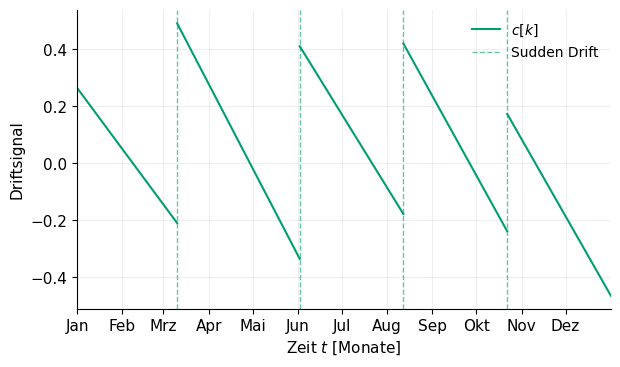

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import locale

STRIDE = 10000

plt.figure(figsize=(fig_width_in, fig_width_in* 0.6))

ax = plt.gca()
ordered_labels = ['$c[k]$', 'Sudden Drift']
for ts_ in data.index[data["segment"]]:
        ax.axvline(x=ts_, label=ordered_labels[1], **ts.vline("drift_event", lw=1.0))

seg_bounds = np.flatnonzero(data["segment"].to_numpy())
seg_starts = np.r_[0, seg_bounds]
seg_ends   = np.r_[seg_bounds, len(data)]

for i, (a, b) in enumerate(zip(seg_starts, seg_ends)):
    idx = np.r_[np.arange(a, b, STRIDE), b - 1]
    ax.plot(data.index[idx], data["cd"].iloc[idx],
            color=ts.C["drift_signal"], lw=1.5, zorder=2,
            label=ordered_labels[0] if i == 0 else None)

plt.margins(x=0)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
try:
    locale.setlocale(locale.LC_TIME, 'de_DE.UTF-8')
except locale.Error:
    pass
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Zeit $t$ [Monate]')

plt.ylabel('Driftsignal')
ax.grid(True, alpha=0.2)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend([by_label[label] for label in ordered_labels if label in by_label],
        ordered_labels, frameon=False)
plt.tight_layout()

plot_store.save_figure(plt.gcf(), "concept_drift", data_cfg, final=IS_FINAL)
plt.show()

## Noise

In [12]:
from typing import NamedTuple
import numpy as np

class GaussianComponent(NamedTuple):
    sigma: float
    weight: float = 1.0

def mixed_gaussian_noise(
    signal: np.ndarray,
    components: list[GaussianComponent],
    appearance_ratio: float = 1.0,
) -> np.ndarray:
    """Additives Gaussian-Mixture-Rauschen; weight wird normiert, appearance_ratio steuert den Anteil verrauschter Samples."""
    weights = np.array([c.weight for c in components])
    weights /= weights.sum()

    n_affected = int(signal.size * appearance_ratio)
    indices = rng.choice(signal.size, n_affected, replace=False)
    component_draws = rng.choice(len(components), size=n_affected, p=weights)

    noisy = np.array(signal, copy=True)
    for k, comp in enumerate(components):
        mask = component_draws == k
        noisy[indices[mask]] += rng.normal(0, comp.sigma, size=mask.sum())

    return noisy

## Creation of setpoints

In [13]:
import pandas as pd

def create_setpoint_series(value_range: tuple[float, float], no_changes: int, idx: np.ndarray) -> pd.Series:
    change_indices = np.sort(rng.choice(len(idx), no_changes, replace=False))
    changes = rng.uniform(value_range[0], value_range[1], no_changes)
    init_value = rng.uniform(value_range[0], value_range[1])
    boundaries = np.r_[0, change_indices, len(idx)]
    segment_values = np.r_[init_value, changes]
    values = np.repeat(segment_values, np.diff(boundaries))
    return pd.Series(values, index=idx)

In [14]:
if not _data_loaded_from_cache:
    data['w1'] = create_setpoint_series(value_range=RANGE_W1, no_changes=N_CHANGES_W1, idx=data.index)
    data['w2'] = create_setpoint_series(value_range=RANGE_W2, no_changes=N_CHANGES_W2, idx=data.index)

Add Concept drift to Setpoints

In [15]:
def cd_setpoint_influence(
    setpoint: pd.Series,
    concept_drift: np.ndarray,
    setpoint_range: tuple[float, float],
    cd_range: tuple[float, float],       # (CD_MIN, CD_MAX)
    factor: float = 1,
) -> pd.Series:
    """w_tilde[k] = w[k] + kappa_w * (c_w[k] - c_mid)."""
    kappa_w = factor * (setpoint_range[1] - setpoint_range[0])
    c_mid = (cd_range[0] + cd_range[1]) / 2          # Nullpunkt des Drifts

    setpoint_change_idx = setpoint.diff().ne(0)
    concept_drift = pd.Series(concept_drift - c_mid, index=setpoint.index)  # re-zentriert
    c_w = concept_drift.where(setpoint_change_idx).ffill().fillna(0)
    return setpoint + kappa_w * c_w

In [16]:
if not _data_loaded_from_cache:
    data["w1_cd"] = cd_setpoint_influence(setpoint=data['w1'], concept_drift=data['cd'].to_numpy(), setpoint_range=RANGE_W1, cd_range=(CD_MIN, CD_MAX), factor=KAPPA_W_FACTOR)
    data["w2_cd"] = cd_setpoint_influence(setpoint=data['w2'], concept_drift=data['cd'].to_numpy(), setpoint_range=RANGE_W2, cd_range=(CD_MIN, CD_MAX), factor=KAPPA_W_FACTOR)

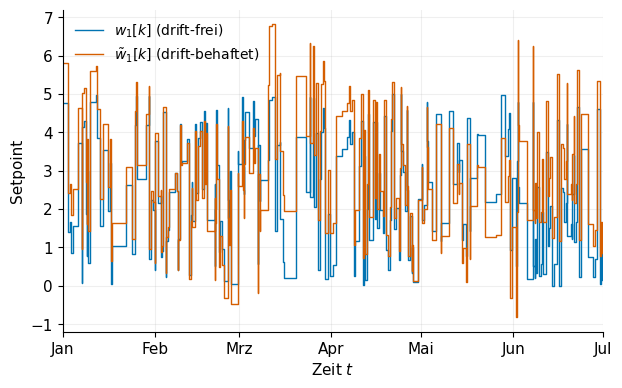

In [17]:
import locale
import matplotlib.pyplot as plt

def reduce_zoh(s: pd.Series) -> pd.Series:
    """Reduziert ein ZOH-Signal auf seine Aenderungspunkte (+ Randpunkte)."""
    keep = s.diff().ne(0)
    keep.iloc[0] = True
    keep.iloc[-1] = True
    return s[keep]

first_win_idx = data.index[0]
last_win_idx = pd.Timestamp("1970-07-01 00:00:00")
win = slice(first_win_idx, last_win_idx)
plt.figure(figsize=(fig_width_in*1.1, fig_width_in*1.1 * 0.6))
plt.plot(reduce_zoh(data.loc[win, "w1"]), drawstyle='steps-post', label=r'$w_1[k]$ (drift-frei)', linewidth=1, color=ts.C["drift_free"])
plt.plot(reduce_zoh(data.loc[win, "w1_cd"]), drawstyle='steps-post', label=r'$\tilde{w}_1[k]$ (drift-behaftet)', linewidth=1, color=ts.C["drift_afflicted"])

plt.margins(x=0)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
try:
    locale.setlocale(locale.LC_TIME, 'de_DE.UTF-8')
except locale.Error:
    pass
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Zeit $t$')

plt.ylabel('Setpoint')
plt.legend(frameon=False, loc="upper left")
ax.grid(True, alpha=0.2)

plot_store.save_figure(plt.gcf(), "setpoints", data_cfg, final=IS_FINAL)
plt.show()

## PT1-Strecke

In [18]:
class PT1:
    def __init__(self, K: float, T: float, Ts: float):
        """PT1 element in discrete time domain (K Gain, T Zeitkonstante, Ts Abtastzeit)."""
        self.K = K
        self.T = T
        self.Ts = Ts
        self.y_prev: float | None = None

    def reset(self, y0: float = None):
        """Reset the output to y0 (or None)."""
        self.y_prev = y0

    def step(self, u: float, y0: float = None) -> float:
        """Calculate the next output value for input u."""
        if self.y_prev is None:
            self.reset(y0 if y0 is not None else u)

        a = self.T / (self.T + self.Ts)
        b = self.K * self.Ts / (self.T + self.Ts)
        y = self._calc_step(a, self.y_prev, b, u)
        self.y_prev = y
        return y

    def _calc_step(self, a: float, y_prev: float, b: float, u: float) -> float:
        return a * y_prev + b * u

class PT1_CD(PT1):
    def __init__(
            self,
            K: float,
            T: float,
            Ts: float,
            K_vary: bool = False,
            T_vary: bool = True,
            ):
        """PT1 element with concept drift in discrete time domain."""
        self.K_vary = K_vary
        self.T_vary = T_vary
        super().__init__(K, T, Ts)

    def step(self, u: float, c: float = None, y0: float = None) -> float:
        """Calculate the next output value for input u, with optional concept drift c."""
        if self.y_prev is None:
            self.reset(y0 if y0 is not None else u)

        if c is None:
            return super().step(u)
        else:
            K = self.K * (1 + c) if self.K_vary else self.K
            T = self.T * (1 + c) if self.T_vary else self.T
            a = T / (T + self.Ts)
            b = K * self.Ts / (T + self.Ts)
            y = self._calc_step(a, self.y_prev, b, u)
            self.y_prev = y
            return y

Simple example of PT1 plant

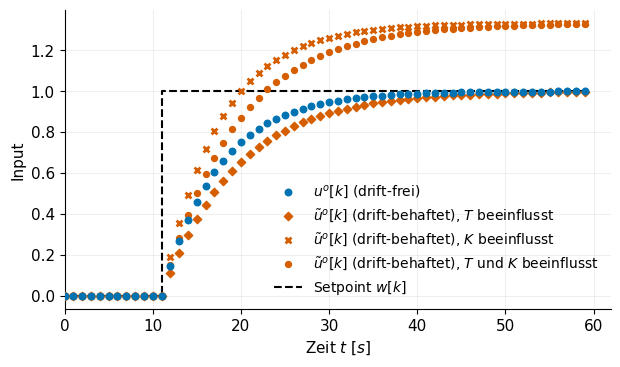

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

K = 1.0
T = 6.0
Ts = 1.0
c_val = 1/3

time_ = np.arange(0, 60, Ts)

w = np.zeros_like(time_, dtype=float)
w[len(time_)//5:] = 1.0

pt1_ref = PT1(K, T, Ts)
u_ref = [pt1_ref.step(u) for u in w]

pt1_T = PT1_CD(K, T, Ts, K_vary=False, T_vary=True)
u_T = [pt1_T.step(u, c=c_val) for u in w]

pt1_K = PT1_CD(K, T, Ts, K_vary=True, T_vary=False)
u_K = [pt1_K.step(u, c=c_val) for u in w]

pt1_both = PT1_CD(K, T, Ts, K_vary=True, T_vary=True)
u_both = [pt1_both.step(u, c=c_val) for u in w]

fig, ax = plt.subplots(1, 1, figsize=(fig_width_in, fig_width_in * 0.6))

ordered_labels = [
    r'$u^o[k]$ (drift-frei)',
    r'$\tilde{u}^o[k]$ (drift-behaftet), $T$ beeinflusst',
    r'$\tilde{u}^o[k]$ (drift-behaftet), $K$ beeinflusst',
    r'$\tilde{u}^o[k]$ (drift-behaftet), $T$ und $K$ beeinflusst',
    r'Setpoint $w[k]$'
]

ax.step(time_, w, where='pre', label=ordered_labels[4], color=ts.C["setpoint"], linestyle='--', linewidth=1.5)
ax.scatter(time_, u_ref, label=ordered_labels[0], zorder=4, **ts.scatter("drift_free", s=22))
for u_var, lbl, mk in [
    (u_both, ordered_labels[3], ts.DRIFT_VARIANT_MARKERS[0]),
    (u_K,    ordered_labels[2], ts.DRIFT_VARIANT_MARKERS[1]),
    (u_T,    ordered_labels[1], ts.DRIFT_VARIANT_MARKERS[2]),
]:
    ax.scatter(time_, u_var, label=lbl, zorder=3, **ts.scatter("drift_afflicted", marker=mk, s=18))

ax.set_xlabel('Zeit $t$ $[s]$')
ax.set_xlim(left=0)
ax.set_ylabel('Input')

handles, labels = ax.get_legend_handles_labels()

label_to_handle = dict(zip(labels, handles))
sorted_handles = [label_to_handle[l] for l in ordered_labels]
ax.legend(sorted_handles, ordered_labels, frameon=False, loc='best')

fig.tight_layout()
ax.grid(True, alpha=0.2)

plot_store.save_figure(fig, "pt1", data_cfg, final=IS_FINAL)
plt.show()

Application of PT1 plant

In [20]:
pt1_plant_1 = PT1(K=K_ACT, T=T_ACT_1, Ts=Ts)
pt1_plant_2 = PT1(K=K_ACT, T=T_ACT_2, Ts=Ts)
if not _data_loaded_from_cache:
    w1_arr = data['w1'].to_numpy()
    w2_arr = data['w2'].to_numpy()

    u1_temp = []
    u2_temp = []

    for idx in range(len(time)):
        u1_temp.append(pt1_plant_1.step(w1_arr[idx]))
        u2_temp.append(pt1_plant_2.step(w2_arr[idx]))

    data['u1'] = u1_temp
    data['u2'] = u2_temp

Add noise

In [21]:
components_u1 = [GaussianComponent(*c) for c in NOISE_U1]
components_u2 = [GaussianComponent(*c) for c in NOISE_U2]
if not _data_loaded_from_cache:
    data['u1_noise'] = mixed_gaussian_noise(
        data['u1'].to_numpy(),
        components = components_u1,
        appearance_ratio=1.0
    )

    data['u2_noise'] = mixed_gaussian_noise(
        data['u2'].to_numpy(),
        components = components_u2,
        appearance_ratio=1.0
    )

Gespeichert.


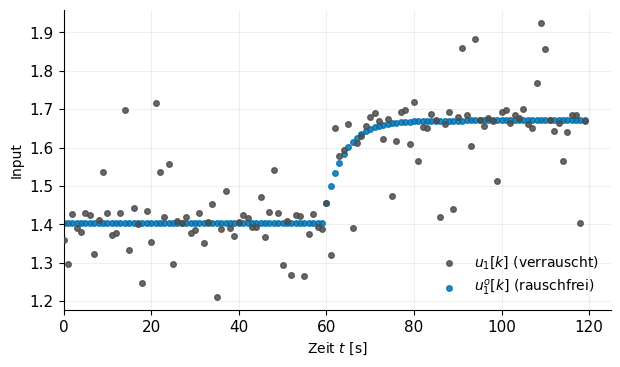

In [22]:
import matplotlib.pyplot as plt

WINDOW_S = 120

jump_idx = data.loc[data["w1"].diff().ne(0), "w1"].index[2]
jump_idx_iloc = data.index.get_loc(jump_idx)
center   = int(jump_idx_iloc // 2)
win_start = max(0, jump_idx_iloc - WINDOW_S // 2)
win_end   = win_start + WINDOW_S

k_plot = np.arange(0, WINDOW_S)
u1_win = data.iloc[win_start:win_end]["u1"]
u1_noise_win = data.iloc[win_start:win_end]["u1_noise"]
t_axis = k_plot * Ts

fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.6))

ax.scatter(t_axis, u1_noise_win, label=r"$u_1[k]$ (verrauscht)", zorder=3, **ts.scatter("noise", s=16, alpha=0.85))
ax.scatter(t_axis, u1_win, label=r"$u^o_1[k]$ (rauschfrei)", zorder=2, **ts.scatter("drift_free", s=16, alpha=0.85))

ax.set_xlim(left=0)
ax.set_xlabel("Zeit $t$ [s]", fontsize=10)
ax.set_ylabel("Input", fontsize=10)

ax.legend(loc="lower right", frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()

plot_store.save_figure(fig, "pt1_noise", data_cfg, final=IS_FINAL)
print("Gespeichert.")
plt.show()

Add drift

In [23]:
if not _data_loaded_from_cache:
    w1_cd_arr = data['w1_cd'].to_numpy()
    w2_cd_arr = data['w2_cd'].to_numpy()
    cd_arr = data['cd'].to_numpy()

    pt1_plant_1 = PT1_CD(K=K_ACT, T=T_ACT_1, Ts=Ts, K_vary=True, T_vary=True)
    pt1_plant_2 = PT1_CD(K=K_ACT, T=T_ACT_2, Ts=Ts, K_vary=True, T_vary=True)
    u1_cd_temp = []
    u2_cd_temp = []

    for idx in range(len(time)):
        u1_cd_temp.append(pt1_plant_1.step(w1_cd_arr[idx], cd_arr[idx]))
        u2_cd_temp.append(pt1_plant_2.step(w2_cd_arr[idx], cd_arr[idx]))

    data["u1_cd"] = u1_cd_temp
    data["u2_cd"] = u2_cd_temp

In [24]:
if not _data_loaded_from_cache:
    data["u1_cd_noise"] = mixed_gaussian_noise(
        data["u1_cd"].to_numpy(),
        components = components_u1,
        appearance_ratio=1.0
    )

    data["u2_cd_noise"] = mixed_gaussian_noise(
        data["u2_cd"].to_numpy(),
        components = components_u2,
        appearance_ratio=1.0
    )

## Output function - Wiener-Modell

In [25]:
import numpy as np
from scipy.signal import fftconvolve

def pt1_impulse_response(K: float, T: float, Ts: float, tol: float = 1e-12) -> np.ndarray:
    a = T / (T + Ts)
    n = int(np.ceil(np.log(tol) / np.log(a)))
    return K * Ts / (T + Ts) * a ** np.arange(n)

def wiener_model(
    u: list[np.ndarray],
    alpha: list[float],
    f: np.ndarray,
    g: callable,
) -> np.ndarray:
    """MISO-Wiener-Modell: Eingangskanaele u, LTI-Block aus Gewichten alpha und Impulsantwort f (stationaere Anfangsbedingung), statische Kennlinie g."""
    s = sum(a * x for a, x in zip(alpha, u))
    s_ext = np.r_[np.full(len(f), s[0]), s]
    v = fftconvolve(s_ext, f)[len(f):len(f) + len(s)]
    return g(v)

In [26]:
f_y = pt1_impulse_response(K=K_P, T=T_Y, Ts=Ts) if T_Y > 0 else np.array([1.0])

if not _data_loaded_from_cache:
    data["y"] = wiener_model(
        [data['u1'].to_numpy(), data['u2'].to_numpy()],
        [ALPHA_1, ALPHA_2], f_y, lambda v: v + BETA * v**3)

Add noise

In [27]:
components_y = [GaussianComponent(*c) for c in NOISE_Y]
if not _data_loaded_from_cache:
    data["y_noise"] = mixed_gaussian_noise(
        data["y"].to_numpy(),
        components = components_y,
        appearance_ratio=1.0
    )

Influence of concept drift on output

In [28]:
if not _data_loaded_from_cache:
    data["y_cd"] = wiener_model(
        [data['u1_cd'].to_numpy(), data['u2_cd'].to_numpy(), data['cd'].to_numpy()],
        [ALPHA_1, ALPHA_2, KAPPA], f_y, lambda v: v + BETA * v**3)

In [29]:
if not _data_loaded_from_cache:
    data["y_cd_noise"] = mixed_gaussian_noise(
        data["y_cd"].to_numpy(),
        components = components_y,
        appearance_ratio=1.0
    )

Gespeichert.


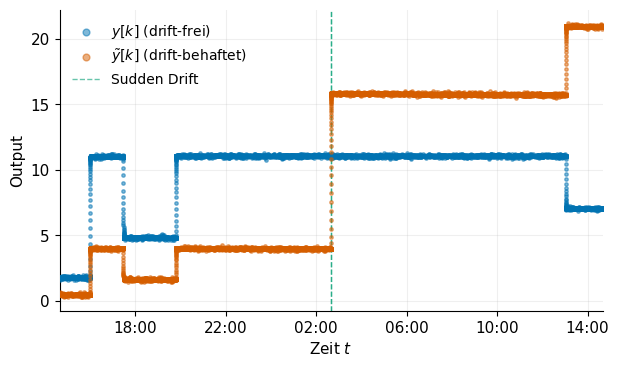

In [30]:
from datetime import timedelta
import matplotlib.dates as mdates

WINDOW_H = 12

poi = data.index[data["segment"]][2]

sl = slice(
    data.index.get_loc(data.index[data.index >= poi - timedelta(hours=WINDOW_H)][0]),
    data.index.get_loc(data.index[data.index <= poi + timedelta(hours=WINDOW_H)][-1]) + 1
)
win = data.iloc[sl]

win_sub = win

C_Y     = ts.C["drift_free"]
C_YCD   = ts.C["drift_afflicted"]
S = 6

fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.6))

for col, color, label in [
    ("y_noise",     C_Y,     r"$y[k]$ (drift-frei)"),
    ("y_cd_noise",  C_YCD,   r"$\tilde{y}[k]$ (drift-behaftet)"),
]:
    ax.scatter(win_sub.index, win_sub[col], color=color, s=S, alpha=0.5, label=label, zorder=3, rasterized=True)

    ax.axvline(x=poi, label="Sudden Drift", **ts.vline("drift_event", lw=1.0))

ax.margins(x=0)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Zeit $t$")
ax.set_ylabel("Output")
handles, labels = ax.get_legend_handles_labels()
seen = {}
for handle, label in zip(handles, labels):
    if label not in seen:
        seen[label] = handle

legend_labels = [lbl for lbl in seen if lbl != "Sudden Drift"] + ["Sudden Drift"]
ax.legend([seen[l] for l in legend_labels], legend_labels, frameon=False, markerscale=2, loc="upper left")
ax.grid(True, alpha=0.2)

fig.tight_layout()

plot_store.save_figure(fig, "wiener_output", data_cfg, final=IS_FINAL, savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
print("Gespeichert.")
plt.show()

In [31]:
if not _data_loaded_from_cache:
    data_store.save(data, "data_raw", data_cfg)

## DOE-Trainingsdatensatz (Latin-Hypercube)

Erzeugt einen kleinen, drift-freien Trainingsdatensatz nach dem Latin-Hypercube-Ansatz (DOE) und speichert `data_doe.pkl` für *synthetic_data_model*.

In [32]:
from scipy.stats import qmc

_doe_loaded_from_cache = data_store.exists("data_doe", data_cfg, rekey=True) and not FORCE_RECOMPUTE

if _doe_loaded_from_cache:
    data_doe = data_store.load("data_doe", data_cfg, rename=True, rekey=True)
else:
    import numpy as np
    import pandas as pd

    W_RANGES   = [RANGE_W1, RANGE_W2]
    pt1_plant_1 = PT1(K=K_ACT, T=T_ACT_1, Ts=Ts)
    pt1_plant_2 = PT1(K=K_ACT, T=T_ACT_2, Ts=Ts)

    lows  = np.array([r[0] for r in W_RANGES])
    highs = np.array([r[1] for r in W_RANGES])
    unit  = qmc.LatinHypercube(d=2, seed=SEED).random(n=N_DOE)
    pts   = qmc.scale(unit, lows, highs)

    w_step  = np.repeat(pts, HOLD_S, axis=0)
    n_doe   = len(w_step)
    bp_id   = np.repeat(np.arange(N_DOE), HOLD_S)
    idx_doe = pd.to_datetime(np.arange(n_doe), unit="s", origin=pd.Timestamp("1970-01-01"))

    data_doe = pd.DataFrame(index=idx_doe)
    data_doe["bp"] = bp_id
    data_doe["w1"] = w_step[:, 0]
    data_doe["w2"] = w_step[:, 1]
    data_doe["u1"] = [pt1_plant_1.step(w) for w in w_step[:, 0]]
    data_doe["u2"] = [pt1_plant_2.step(w) for w in w_step[:, 1]]

    _rng_saved = rng
    rng = np.random.default_rng(SEED)
    try:
        data_doe["u1_noise"] = mixed_gaussian_noise(data_doe["u1"].to_numpy(), components=components_u1, appearance_ratio=1.0)
        data_doe["u2_noise"] = mixed_gaussian_noise(data_doe["u2"].to_numpy(), components=components_u2, appearance_ratio=1.0)

        data_doe["y"] = wiener_model([data_doe["u1"].to_numpy(), data_doe["u2"].to_numpy()], [ALPHA_1, ALPHA_2], f_y, lambda v: v + BETA * v**3)
        data_doe["y_noise"] = mixed_gaussian_noise(data_doe["y"].to_numpy(), components=components_y, appearance_ratio=1.0)
    finally:
        rng = _rng_saved

    data_store.save(data_doe, "data_doe", data_cfg)

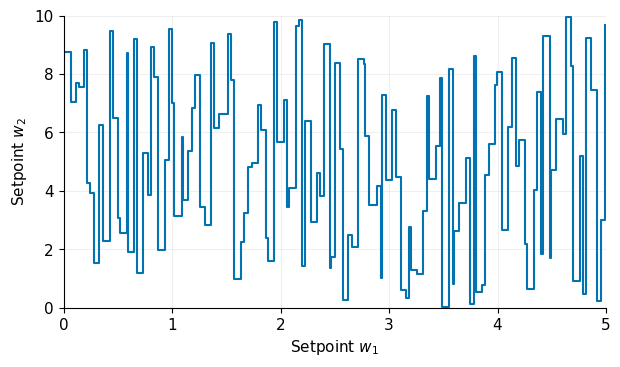

In [33]:
import matplotlib.pyplot as plt

bp_first = data_doe.groupby("bp")[["w1", "w2"]].first()
fig, ax = plt.subplots(figsize=(fig_width_in, fig_width_in * 0.6))
bp_plot = bp_first.sort_values("w1")
ax.step(bp_plot["w1"], bp_plot["w2"], where="post", color=ts.C["drift_free"], linewidth=1.5)
ax.set_xlabel(r"Setpoint $w_1$")
ax.set_ylabel(r"Setpoint $w_2$")
ax.set_xlim(0, 5)
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

## Parameter speichern

In [34]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus syn_generation.ipynb - nicht manuell editieren")
mx.comment("Parameter (Hash-relevant, Basis-Config)")
mx.param("paramGammaTau",  run_cfg["gamma_tau"], is_frac=False, nd=1)
mx.param("paramKp",        run_cfg["K_p"])
mx.param("paramCdBandDiv", run_cfg["cd_band_div"])
mx.param("paramNSeg",     run_cfg["num_segments"])
mx.param("paramCdMin",    run_cfg["cd_range"][0], is_frac=False)
mx.param("paramCdMax",    run_cfg["cd_range"][1], is_frac=False)
mx.param("paramAlphaOne", run_cfg["alpha"][0])
mx.param("paramAlphaTwo", run_cfg["alpha"][1])
mx.param("paramBeta",     run_cfg["beta"])
mx.param("paramKappaY",   run_cfg["kappa"])
mx.param("paramTy",       run_cfg["T_y"], unit=r"\second")
mx.param("paramTs",       run_cfg["Ts"], unit=r"\second")
mx.param("paramFs",        1.0 / run_cfg["Ts"], unit=r"\hertz")

mx.save(res_store, "generation", data_cfg, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\syn_generation.tex

% automatisch erzeugt aus syn_generation.ipynb - nicht manuell editieren

% Parameter (Hash-relevant, Basis-Config)
\newcommand{\paramGammaTau}{0{,}2}
\newcommand{\paramKp}{1}
\newcommand{\paramCdBandDiv}{4}
\newcommand{\paramNSeg}{5}
\newcommand{\paramCdMin}{-0{,}5}
\newcommand{\paramCdMax}{0{,}5}
\newcommand{\paramAlphaOne}{\tfrac{2}{5}}
\newcommand{\paramAlphaTwo}{\tfrac{1}{3}}
\newcommand{\paramBeta}{\tfrac{1}{5}}
\newcommand{\paramKappaY}{\tfrac{3}{8}}
\newcommand{\paramTy}{\SI{3}{\second}}
\newcommand{\paramTs}{\SI{1}{\second}}
\newcommand{\paramFs}{\SI{1}{\hertz}}



'C:\\git\\process_optimization_concept_drift\\results\\syn_generation.tex'

In [35]:
from utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Simulation beendet.\nData Run-ID: {run_id}",
    copy_value=run_id,
)


--- Lauf abgeschlossen ---
Simulation beendet.
Data Run-ID: 3d16c559

